## Welcome to Machine Learning!
### What You'll Learn:
1. Importing libraries
2. Loading and exploring data
3. Handling missing values
4. Encoding categorical variables
5. Feature selection and engineering
6. Data visualization
7. Handling imbalanced data
8. Training multiple ML models (KNN, Decision Tree, SVM, Naive Bayes)
9. Evaluating and comparing models
10. Saving and loading models
11. Making predictions on new data

## 1. Import Required Libraries

Install all package at once

pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn joblib

pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn joblib

In [7]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Machine learning modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2, f_classif
# ML Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Handle imbalanced data
from imblearn.over_sampling import SMOTE
# Model persistence
import joblib
# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

Matplotlib is building the font cache; this may take a moment.


### Exercise 1: Import Additional Library

**Task:** Import the `warnings` library and suppress all warnings
- `from scipy import stats` for statistical operations
- Set the random seed for reproducibility using `np.random.seed(42)`

Write your code in the cell below 🔽

## 2. Load Dataset from CSV

In [ ]:
# Load the dataset
df = pd.read_csv("iris.csv")
# Display first 5 rows
print("First 5 rows of the dataset:")
df.head()

### Exercise 2: Explore Basic DataFrame Operations

**Tasks:**
1. Display the **last 5 rows** of the dataset using `df.tail()`
2. Show the **shape** of the dataset (number of rows and columns)
3. Display all **column names**

Write your code below 🔽

## 3. Dataset Exploration

In [ ]:
# Get basic information about the dataset
print("Dataset Information:")
df.info()

In [ ]:
# Statistical summary of numerical columns
print("Statistical Summary:")
df.describe()

In [ ]:
# Check unique target classes
print("Target classes:", df['species'].unique())
print("Number of classes:", df['species'].nunique())

### Exercise 3: Class Distribution Analysis

**Tasks:**
1. Count the number of samples for each species using `value_counts()`
2. Calculate the percentage of each class

Write your code below 🔽

## 4. Handle Missing Values

In [ ]:
# Check for missing values
print("Missing values in each column:")
df.isnull().sum()

The Iris dataset is clean! But let's learn how to handle missing values by artificially creating some.

In [ ]:
# Create a copy with missing values for practice
df_with_nulls = df.copy()
# Introduce missing values in first 5 rows of sepal_length
df_with_nulls.loc[0:4, 'sepal.length'] = np.nan
# Introduce missing values in first 3 rows of species
df_with_nulls.loc[0:2, 'species'] = np.nan
print("Dataset with missing values:")
df_with_nulls.head(10)

In [ ]:
# Check missing values in our practice dataset
print("Missing values in practice dataset:")
df_with_nulls.isnull().sum()

### Exercise 4: Handle Missing Values

**Tasks:**
1. Fill missing numerical values (sepal_length) with **mean**
2. Fill missing categorical values (species) with **mode**

work on the `df_with_nulls` dataset

Write your code below 🔽

In [ ]:
# Method 1: Mean imputation for numerical
df_mean_filled = df_with_nulls.copy()
df_mean_filled['sepal.length'] = df_mean_filled['sepal.length'].fillna(
    df_mean_filled['sepal.length'].mean()
)
# Method 2: Mode imputation for categorical
df_mean_filled['species'] = df_mean_filled['species'].fillna(
    df_mean_filled['species'].mode()[0]
)
print("After mean/mode imputation:")
print(df_mean_filled.isnull().sum())

### Exercise 5: Practice Label Encoding

**Tasks:**
1. Encode the species column using LabelEncoder (as shown above)
2. Create a new column 'species_encoded'
3. Display the first 10 rows showing both original and encoded values
4. Try using `pd.get_dummies()` for one-hot encoding as an alternative

Write your code below 🔽

## 6. Feature Selection

In [ ]:
# Prepare features and target
X = df.drop('species', axis=1)
y = df['species']
# Apply SelectKBest to find top features
selector = SelectKBest(score_func=f_classif, k=3)
X_selected = selector.fit_transform(X, y)
# Get selected feature names
selected_features = X.columns[selector.get_support()].tolist()
print(f"Top {len(selected_features)} features:", selected_features)
# Display feature scores
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)
print("\nFeature scores:")
feature_scores

### Exercise 6: Feature Selection Practice

**Tasks:**
1. Select the **top 2 features** using SelectKBest
2. Print the names of the selected features
3. Create a new DataFrame with only these 2 features

Write your code below:

## 7. Feature Engineering

In [ ]:
# Create a copy for feature engineering
df_fe = df.copy()
# Create petal ratio feature
df_fe['petal_ratio'] = df_fe['petal.length'] / df_fe['petal.width']
# Create sepal area feature
df_fe['sepal_area'] = df_fe['sepal.length'] * df_fe['sepal.width']
# Create petal area feature
df_fe['petal_area'] = df_fe['petal.length'] * df_fe['petal.width']
print("Dataset with engineered features:")
df_fe[['sepal.length', 'sepal.width', 'petal.length', 'petal.width',
       'petal_ratio', 'sepal_area', 'petal_area', 'species']].head()

### Exercise 7: Create Your Own Feature

**Tasks:**
1. Create another derived feature (e.g., sepal_ratio = sepal_length/sepal_width)
2. Add it to the dataframe
3. Display the first 5 rows with your new feature

Write your code below 🔽

## 8. Data Visualization

In [ ]:
# Class distribution bar plot
plt.figure(figsize=(6, 4))
class_counts = df['species'].value_counts()
bars = plt.bar(class_counts.index, class_counts.values, color=['blue', 'orange', 'green'])
plt.title('Class Distribution in Iris Dataset')
plt.xlabel('Species')
plt.ylabel('Count')
# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')
plt.show()

In [ ]:
# Histogram of features
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
features = ['sepal.length', 'sepal.width', 'petal.length', 'petal.width']
for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    for species in df['species'].unique():
        subset = df[df['species'] == species]
        axes[row, col].hist(subset[feature], alpha=0.7, label=species, bins=15)
    axes[row, col].set_title(f'Distribution of {feature}')
    axes[row, col].legend()
plt.tight_layout()
plt.show()

In [ ]:
# Boxplot to check for outliers
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    sns.boxplot(x='species', y=feature, data=df, ax=axes[row, col])
    axes[row, col].set_title(f'Boxplot of {feature} by Species')
plt.tight_layout()
plt.show()

### Exercise 8: Create Your Own Visualization

**Tasks:**
1. Create a **scatter plot** between two features of your choice
2. Color the points by species
3. Add appropriate labels and title
4. Create a bar plot showing class distribution

Write your code below 🔽

## 9. Data Transformation

In [ ]:
from sklearn.preprocessing import MinMaxScaler
# Copy for Min-Max scaling
df_minmax = df.copy()
# Apply Min-Max scaling to 'sepal_width'
minmax_scaler = MinMaxScaler()
df_minmax['sepal_width_minmax']= minmax_scaler.fit_transform(df_minmax[['sepal.width']])
# Compare original vs Min-Max scaled
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Original
axes[0].hist(df_minmax['sepal.width'], bins=20, edgecolor='black', color='skyblue')
axes[0].set_title('Original Sepal Width')
axes[0].set_xlabel('Sepal Width')
axes[0].set_ylabel('Frequency')
# Min-Max scaled
axes[1].hist(df_minmax['sepal_width_minmax'], bins=20, edgecolor='black', color='purple')
axes[1].set_title('Min-Max Scaled Sepal Width')
axes[1].set_xlabel('Scaled Sepal Width (0-1)')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

### Exercise 9: Apply Transformation

**Tasks:**
1. Apply **square root transformation** to sepal_length
2. Apply **standardization** (z-score) to petal_width
3. Visualize the transformed features

Write your code below 🔽

## 10. Class Balance Check and SMOTE

In [ ]:
# Check original class distribution
print("Original class distribution:")
print(df['species'].value_counts())
# Create imbalanced dataset for practice
df_imbalanced = df.copy()
# Remove some samples from two classes to create imbalance
df_imbalanced = pd.concat([
    df_imbalanced[df_imbalanced['species'] == 'Setosa'].iloc[:50],
    df_imbalanced[df_imbalanced['species'] == 'Versicolor'].iloc[:20],
    df_imbalanced[df_imbalanced['species'] == 'Virginica'].iloc[:30]
])
print("\nImbalanced class distribution:")
print(df_imbalanced['species'].value_counts())

In [ ]:
# Prepare features and target for SMOTE
X_imb = df_imbalanced.drop('species', axis=1)
y_imb = df_imbalanced['species']
# Encode target for SMOTE
y_imb_encoded = label_encoder.fit_transform(y_imb)
# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_imb, y_imb_encoded)
# Check balanced distribution
print("After SMOTE - class distribution:")
unique, counts = np.unique(y_resampled, return_counts=True)
for class_label, count in zip(unique, counts):
    print(f"Class {label_encoder.inverse_transform([class_label])[0]}: {count} samples")
print(f"\nOriginal dataset size: {len(X_imb)}")
print(f"After SMOTE dataset size: {len(X_resampled)}")

### Exercise 10: Practice with SMOTE

**Tasks:**
1. Artificially create a more severe class imbalance (e.g., 50-10-5 samples)
2. Apply SMOTE to balance the dataset
3. Compare class distributions before and after SMOTE
4. Visualize the comparison using bar plots

Write your code below 🔽

## 11. Train/Test Split

In [ ]:
# Use original clean dataset
X = df.drop('species', axis=1)
y = df['species']
# Encode target
y_encoded = label_encoder.fit_transform(y)
# Split 80-20
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")
print(f"\nTraining set class distribution:")
train_counts = np.bincount(y_train)
for i, count in enumerate(train_counts):
    print(f"Class {label_encoder.inverse_transform([i])[0]}: {count} samples")
print(f"\nTest set class distribution:")
test_counts = np.bincount(y_test)
for i, count in enumerate(test_counts):
    print(f"Class {label_encoder.inverse_transform([i])[0]}: {count} samples") 

### Exercise 11: Experiment with Different Splits

**Tasks:**
1. Create a 70/30 split
2. Create a 60/40 split
3. Compare the class distribution in each split
4. Try a split without stratification and observe the difference

Write your code below 🔽

## 12. Feature Scaling

In [ ]:
# Initialize scalers
minmax_scaler = MinMaxScaler()
# Fit and transform training data, transform test data
X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)
# Compare original vs scaled
print("Original training data statistics:")
print(pd.DataFrame(X_train, columns=X.columns).describe().loc[['mean', 'std', 'min', 'max']])
print("\nMinMaxScaled training data statistics:")
print(pd.DataFrame(X_train_minmax, columns=X.columns).describe().loc[['mean', 'std', 'min', 'max']])

### Exercise 12: Apply StandardScaler

**Tasks:**
1. Apply **StandardScaler** (z-score normalization) to the features
2. Compare the statistics before and after scaling
3. Visualize the distribution of one feature before and after scaling

Write your code below 🔽

## 13. Model Training

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5) # Initialize KNN
knn_model.fit(X_train_minmax, y_train) # Train
y_pred_knn = knn_model.predict(X_test_minmax) # Predict
acc_knn = accuracy_score(y_test, y_pred_knn) # Accuracy
print(f"KNN model trained. Accuracy: {acc_knn:.4f}")

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_minmax, y_train)
y_pred_dt = dt_model.predict(X_test_minmax)
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree model trained. Accuracy: {acc_dt:.4f}")

In [ ]:
svm_model = SVC(random_state=42)
svm_model.fit(X_train_minmax, y_train)
y_pred_svm = svm_model.predict(X_test_minmax)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM model trained. Accuracy: {acc_svm:.4f}")

In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train_minmax, y_train)
y_pred_nb = nb_model.predict(X_test_minmax)
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes model trained. Accuracy: {acc_nb:.4f}")

### Exercise 13: Experiment with Hyperparameters (GridSearch)

**Tasks:**
1. Change KNN's n_neighbors to 3, 7, and 9
2. Change Decision Tree's max_depth to 3, 5, and 10
3. Change SVM's kernel to 'linear', 'poly', and 'rbf'
4. Train each variation and observe the differences

Write your code below:

## 14. Model Evaluation

In [ ]:
# Function to evaluate and print metrics
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n{'='*50}")
    print(f"{model_name} Model Evaluation")
    print(f"{'='*50}")
    print(f"Accuracy: {accuracy:.4f}")
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    return accuracy
# Evaluate all models
trained_models = {
    "KNN": knn_model,
    "Decision Tree": dt_model,
    "SVM": svm_model,
    "Naive Bayes": nb_model
}
results = {}
for name, model in trained_models.items():
    acc = evaluate_model(model, X_test_minmax, y_test, name)
    results[name] = acc

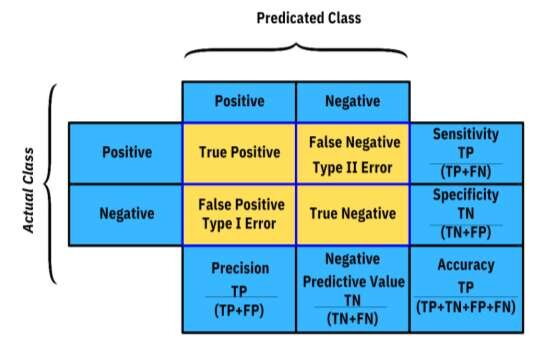

### Exercise 14: Compare Model Evaluations

**Tasks:**
1. Choose the best performing model from above
2. Evaluate it using different metrics (precision, recall, f1-score)
3. Create a visualization comparing the performance of all models

Write your code below 🔽

## 15. Model Comparison Table

In [ ]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['KNN', 'Decision Tree', 'SVM', 'Naive Bayes'],
    'Accuracy': [acc_knn, acc_dt, acc_svm, acc_nb]
})
# Add macro metrics
for model_name, y_pred in zip(['KNN', 'Decision Tree', 'SVM', 'Naive Bayes'],
                              [y_pred_knn, y_pred_dt, y_pred_svm, y_pred_nb]):
    report = classification_report(y_test, y_pred, output_dict=True)
    comparison_df.loc[comparison_df['Model'] == model_name, 'Precision (macro)'] = report['macro avg']['precision']
    comparison_df.loc[comparison_df['Model'] == model_name, 'Recall (macro)'] = report['macro avg']['recall']
    comparison_df.loc[comparison_df['Model'] == model_name, 'F1-Score (macro)'] = report['macro avg']['f1-score']
# Sort by accuracy
comparison_df = comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print("Model Performance Comparison:")
display(comparison_df)

### Exercise 15: Identify Best Model

**Tasks:**
1. Based on the comparison table, identify the best performing model
2. Explain why you think it performed best
3. Create a bar plot comparing all metrics (Accuracy, Precision, Recall, F1-Score) for all models

Write your code below 🔽

## 16. Model Saving

In [ ]:
# Find best model based on accuracy
best_model_name = comparison_df.iloc[0]['Model']
model_mapping = {
    "KNN": knn_model,
    "Decision Tree": dt_model,
    "SVM": svm_model,
    "Naive Bayes": nb_model
}
best_model_to_save = model_mapping[best_model_name]
print(f"Best model selected: {best_model_name}")

In [ ]:
from sklearn.pipeline import Pipeline
# Create a pipeline with scaling and the best model
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('model', best_model_to_save)
])
# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)
# Save the entire pipeline
joblib.dump(pipeline, f'{best_model_name.lower().replace(" ", "_")}_pipeline.pkl')
print(f"Pipeline saved as {best_model_name.lower().replace(' ', '_')}_pipeline.pkl")

### Exercise 16: Save Another Model

**Tasks:**
1. Choose another trained model (not the best one)
2. Save it to a file using joblib
3. Verify the file was created

Write your code below 🔽

## 17. Model Loading

In [ ]:
# Load the saved pipeline (includes scaler + model)
pipeline_filename = f"{best_model_name.lower().replace(' ', '_')}_pipeline.pkl"
loaded_pipeline = joblib.load(pipeline_filename)
print(f"Pipeline loaded from '{pipeline_filename}'")
# Verify that the loaded pipeline works
# No need to manually scale X_test — the pipeline handles it
sample_pred = loaded_pipeline.predict(X_test[:5])
# If your target was label-encoded, decode it
sample_pred_labels = label_encoder.inverse_transform(sample_pred)
actual_labels = label_encoder.inverse_transform(y_test[:5])
print("\nSample predictions from loaded pipeline:")
print("Predicted:", sample_pred_labels)
print("Actual:   ", actual_labels)

### Exercise 17: Load and Test Another Model

**Tasks:**
1. Load the DT model you saved earlier
2. Make predictions on the test set
3. Calculate its accuracy and compare with the original DT accuracy

Write your code below 🔽

## 18. Prediction on New Data

In [ ]:
# Define new samples (sepal_length, sepal_width, petal_length, petal_width)
new_samples = [
    [5.1, 3.5, 1.4, 0.2],
    [6.5, 3.0, 5.2, 2.0],
    [5.9, 2.8, 4.1, 1.3],
]
# Convert to DataFrame (optional, but keeps column names)
new_samples_df = pd.DataFrame(new_samples, columns=X.columns)
# Predict using the loaded pipeline (scaling + model handled internally)
predictions = loaded_pipeline.predict(new_samples_df)
# Decode labels to species names
predicted_species = label_encoder.inverse_transform(predictions)
# Display results
print("Predictions on New Data:")
print("-" * 50)
for i, (sample, species) in enumerate(zip(new_samples, predicted_species)):
    print(f"Sample {i+1}: {sample} -> Predicted: {species}")

### Exercise 18: Make Your Own Predictions

**Tasks:**
1. Create 3 new samples of your own with different feature values
2. Use the loaded model to predict their species
3. Are the predictions what you expected?

Write your code below 🔽

## Final Challenge

As a final exercise, try to:
1. Add a new classifier (e.g., Random Forest)
2. Perform hyperparameter tuning using GridSearchCV
3. Create a pipeline that combines all preprocessing steps
4. Deploy your model as a simple web app using Streamlit or Flask